In [36]:
## LLM GENERATED

import pandas as pd
import re

# ——————————————————————————————————————————————
# 1. Load your data (or assume `gb1900` is already a DataFrame)

gb1900 = pd.read_csv('../data/original/gb1900_gazetteer_complete_july_2018.csv', encoding='utf-16')

# ——————————————————————————————————————————————

# 2. Filter out one‐ and two‐letter “abbreviations”
abbrs = {
    'F. P.', 'W', 'P', 'F. B.', 'S. P.', 'S. Ps.', 'G. P',
    'B. S.', 'M. S.', 'M. P', 'B. R.', 'B. P.', 'L. B', 'P. O.'
}
pat_abbr = re.compile(r'^[A-Z](?:\.\s?)?(?:[A-Z]\.?)?$')

df_clean = gb1900.loc[
    ~(
        gb1900['final_text'].isin(abbrs) |
        gb1900['final_text'].str.match(pat_abbr)
    )
].copy()

# ——————————————————————————————————————————————
# 3. Define an expanded list of INDUSTRIAL terms
#    (from our project discussions on mills, foundries, warehouses, etc.)
# ——————————————————————————————————————————————
industrial_terms = [
    'Mill', 'Malthouse', 'Brewery', 'Factory', 'Warehouse',
    'Works', 'Engine House', 'Smithy', 'Gasometer', 'Saw Mill',
    'Brick Works', 'Tile Works', 'Pottery', 'Foundry', 'Ironworks',
    'Glassworks', 'Forge', 'Distillery', 'Oil Works', 'Rolling Mill',
    'Steam Engine House'
]

# build a single regex that matches any of the above (word‐boundaried)
pat_industrial = re.compile(
    r'\b(' + '|'.join(re.escape(term) for term in industrial_terms) + r')\b',
    re.IGNORECASE
)

# ——————————————————————————————————————————————
# 4. Filter to industrial entries only
# ——————————————————————————————————————————————
df_industrial = df_clean.loc[
    df_clean['final_text'].str.contains(pat_industrial, na=False)
].copy()

# ——————————————————————————————————————————————
# 5. Write out to CSV


print(f"Wrote {len(df_industrial)} industrial records to industrial_buildings.csv")


/var/folders/35/7877ljzn6nj5tdww9cfrpbz40000gn/T/ipykernel_65250/1598161542.py:9: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  gb1900 = pd.read_csv('../data/original/gb1900_gazetteer_complete_july_2018.csv', encoding='utf-16')
/var/folders/35/7877ljzn6nj5tdww9cfrpbz40000gn/T/ipykernel_65250/1598161542.py:49: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_clean['final_text'].str.contains(pat_industrial, na=False)


Wrote 53972 industrial records to industrial_buildings.csv


In [38]:
import pandas as pd

# assume you already have df_industrial loaded

# 1. explicit drops
to_drop = ['pin_id', 'notes']

# 2. collect all "osgb_*" columns dynamically
to_drop += [col for col in df_industrial.columns
            if col.lower().startswith('osgb_')]

# 3. drop them safely
df_clean = df_industrial.drop(columns=to_drop, errors='ignore')

df_clean.rename(columns={
    'final_text': 'name',
    'local_authority': 'county',
    # ...
}, inplace=True)

# 4. write out
df_clean.to_csv('industrial_buildings.csv', index=False)

print("Dropped columns:", to_drop)
print("Remaining columns:", df_clean.columns.tolist())


Dropped columns: ['pin_id', 'notes', 'osgb_east', 'osgb_north']
Remaining columns: ['name', 'nation', 'county', 'parish', 'latitude', 'longitude']


In [42]:
industry_df = pd.read_csv("industrial_buildings.csv")

Generated pie_chart.html with a non‐overlapping legend.


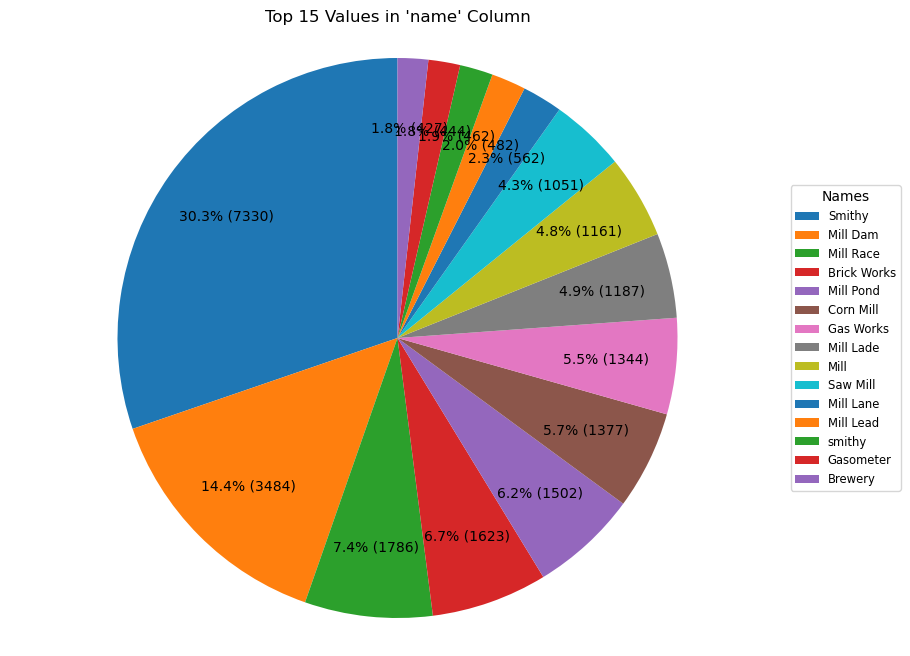

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from io import BytesIO
import base64



# 2. Compute the top 15 most frequent values in 'name'
top15 = industry_df['name'].value_counts().nlargest(15)
labels = top15.index.tolist()
sizes  = top15.values.tolist()

# 3. Helper to show “X.Y% (N)” on each slice
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}% ({count})"
    return my_autopct

# 4. Draw the pie, but omit the wedge‐labels; use pctdistance to move autopct inward
fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    autopct=make_autopct(sizes),
    startangle=90,
    pctdistance=0.75
)
ax.axis('equal')
plt.title("Top 15 Values in 'name' Column")

# 5. Put all the labels in a legend so they never overlap
ax.legend(
    wedges,
    labels,
    title="Names",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize='small'
)

# 6. Encode as base64 and build HTML (same as before)
buf = BytesIO()
fig.savefig(buf, format='png', bbox_inches='tight')
buf.seek(0)
img_base64 = base64.b64encode(buf.read()).decode('utf-8')

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <title>Pie Chart: Top 15 Names</title>
</head>
<body>
  <h2>Distribution of Top 15 Names</h2>
  <img src="data:image/png;base64,{img_base64}" alt="Pie chart of top 15 names">
</body>
</html>
"""

with open('pie1.html', 'w') as f:
    f.write(html)

print("Generated pie_chart.html with a non‐overlapping legend.")


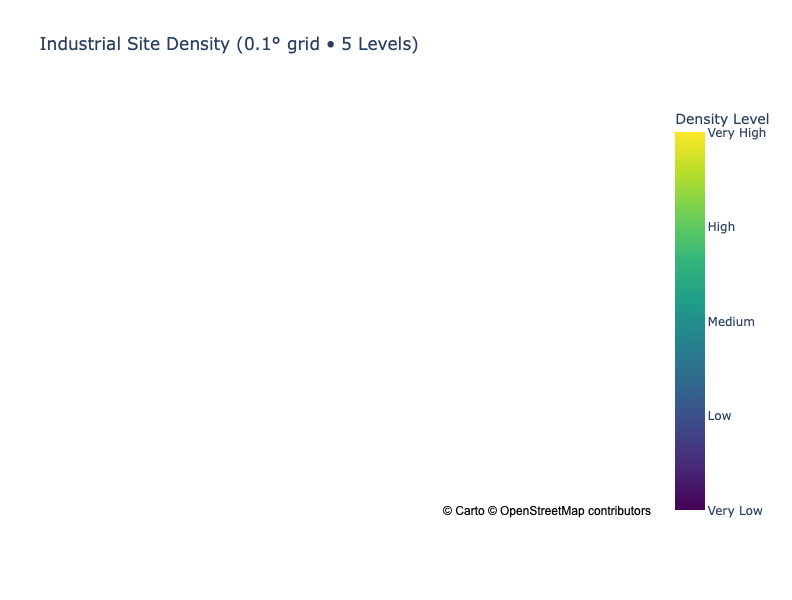

In [64]:
import pandas as pd
import plotly.express as px

# 1. Load your full dataset
df_power = pd.read_csv('../data/processed/industrial_buildings.csv')  

# 2. Thin out 50 k+ points by aggregating to a 0.1° grid
df_grid = (
    df_power
      .assign(
        latitude  = df_power['latitude'].round(1),
        longitude = df_power['longitude'].round(1)
      )
      .groupby(['latitude','longitude'], as_index=False)
      .size()
      .rename(columns={'size': 'count'})
)

# 3. (Optional) remove cells with only one site
df_grid = df_grid[df_grid['count'] > 1]

# 4. Compute percentile rank & cut into 5 levels
df_grid['pct_rank'] = df_grid['count'].rank(pct=True)
bins   = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['Very Low','Low','Medium','High','Very High']

df_grid['density_level'] = pd.cut(
    df_grid['pct_rank'],
    bins=bins,
    labels=labels,
    include_lowest=True
)
df_grid.drop(columns='pct_rank', inplace=True)

# 5. Convert levels to numeric codes so we can use a continuous scale
df_grid['density_code'] = df_grid['density_level'].cat.codes

# 6. Plot: size by count, color by density_code on a Viridis scale
fig = px.scatter_mapbox(
    df_grid,
    lat='latitude',
    lon='longitude',
    size='count',
    size_max=25,
    opacity=0.6,
    color='density_code',
    color_continuous_scale='Viridis',
    range_color=[0, len(labels)-1],
    zoom=5,
    mapbox_style='carto-positron',
    title='Industrial Site Density (0.1° grid • 5 Levels)',
    width=800,
    height=600
)

# 7. Center the map on the data
fig.update_layout(
    mapbox=dict(
        center=dict(
            lat=df_power['latitude'].mean(),
            lon=df_power['longitude'].mean()
        )
    )
)

# 8. Tweak the colorbar: show discrete ticks labeled with our level names
fig.update_coloraxes(
    colorbar=dict(
        tickmode='array',
        tickvals=list(range(len(labels))),
        ticktext=labels,
        title='Density Level'
    )
)

# 9. Export to HTML
fig.write_html("map1.html", include_plotlyjs="cdn")

fig


In [120]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# 1) Load
df = pd.read_csv('industrial_buildings.csv')

# 2) Base map
m = folium.Map(
    location=[df.latitude.mean(), df.longitude.mean()],
    zoom_start=6,
    tiles='CartoDB positron'
)

# 3) Prepare heat data
heat_data = df[['latitude','longitude']].values.tolist()

# 4) String-keyed gradient
gradient = {
    '0.2': 'blue',
    '0.4': 'lime',
    '0.6': 'yellow',
    '0.8': 'orange',
    '1.0': 'red'
}

# 5) Add the HeatMap
HeatMap(
    heat_data,
    min_opacity=0.2,
    radius=8,
    blur=12,
    max_zoom=12,
    use_local_extrema=True,
    gradient=gradient
).add_to(m)

# 6) Save or display
m.save('map2.html')


In [131]:
import pandas as pd
import folium
from folium.plugins import HeatMap, MarkerCluster

# 1) Load all your sites
df = pd.read_csv('industrial_buildings.csv')

# 2) Define a wider bounding box for Manchester + suburbs
lat_min, lat_max = 53.20, 53.70   # ~53.2°N to 53.7°N
lon_min, lon_max = -2.60, -1.70   # ~2.6°W to 1.7°W

df_area = df[
    df.latitude.between(lat_min, lat_max) &
    df.longitude.between(lon_min, lon_max)
]

# 3) Center map on that region
center = [df_area.latitude.mean(), df_area.longitude.mean()]
m = folium.Map(location=center, zoom_start=11, tiles='CartoDB positron')

# 4) HeatMap of all points in that box
heat_data = df_area[['latitude','longitude']].values.tolist()
HeatMap(
    heat_data,
    radius=15,
    blur=20,
    min_opacity=0.3,
    max_zoom=13
).add_to(m)

# 5) MarkerCluster with popups
cluster = MarkerCluster(name='Sites').add_to(m)
for _, row in df_area.iterrows():
    folium.Marker(
        [row.latitude, row.longitude],
        popup=(
            f"<b>{row.get('name','Power Site')}</b><br>"
            f"Lat: {row.latitude:.4f}<br>"
            f"Lon: {row.longitude:.4f}"
        )
    ).add_to(cluster)

# 6) Layer control & save
folium.LayerControl().add_to(m)
m.save('map3.html')
m

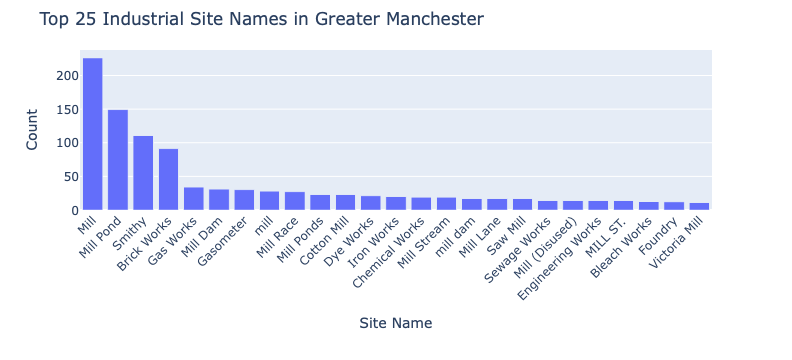

In [149]:
import pandas as pd
import plotly.express as px

# 1) Read & filter as before
df = pd.read_csv('industrial_buildings.csv')
lat_min, lat_max = 53.20, 53.70
lon_min, lon_max = -2.60, -1.70
df_area = df[
    df.latitude.between(lat_min, lat_max) &
    df.longitude.between(lon_min, lon_max)
]

# 2) Build the top-10 table with proper column names
top10 = (
    df_area['name']
      .value_counts()               # Series: index=name, values=count
      .nlargest(25)                 # keep top 10
      .rename_axis('name')          # give the SERIES index a name
      .reset_index(name='count')    # turn it into a DF with columns ['name','count']
)

# 3) Make the Plotly bar chart
fig = px.bar(
    top10,
    x='name',
    y='count',
    title='Top 25 Industrial Site Names in Greater Manchester',
    labels={'name':'Site Name','count':'Count'}
)
fig.update_layout(xaxis_tickangle=-45, margin=dict(t=50,b=150))

# 4) Export to HTML
fig.write_html(
    'bar1.html',
    include_plotlyjs='cdn'
)
fig

Chart written to bar2.html


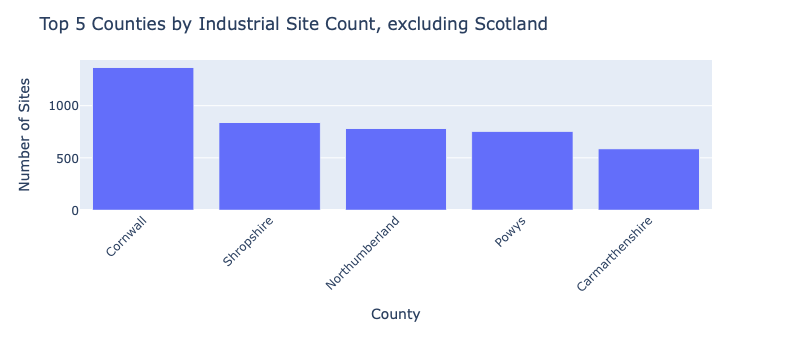

In [163]:
import pandas as pd
import plotly.express as px

# 1) Load your data (adjust the path if needed)
df = pd.read_csv('industrial_buildings.csv')

# 2) Exclude Scottish entries
df_non_scot = df[df['nation'] != 'Scotland']

# 3) Compute the top-10 counties by site count
top10 = (
    df_non_scot['county']
      .value_counts()
      .nlargest(5)
      .reset_index(name='count')
      .rename(columns={'index':'county'})
)

# 4) Build the Plotly bar chart
fig = px.bar(
    top10,
    x='county',
    y='count',
    title='Top 5 Counties by Industrial Site Count, excluding Scotland',
    labels={'county':'County','count':'Number of Sites'}
)
fig.update_layout(xaxis_tickangle=-45, margin=dict(t=60,b=150))

# 5) Save as standalone HTML
out_file = 'bar2.html'
fig.write_html(out_file, include_plotlyjs='cdn')
print(f"Chart written to {out_file}")

# 6) (Optional) display in notebook
fig.show()
